<a href="https://colab.research.google.com/github/rawalnidhi/Global-Data-Breach-Analysis/blob/main/notebooks/Global_Data_Breach_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Global Data Breach Analysis: Industry Risk, Attack Methods, and Breach Impact


## Project Objective

Analyze historical global data breach incidents to identify industry risk patterns, common attack methods, and trends in breach severity over time.

## Business Problem

Organizations across industries continue to experience increasingly severe cybersecurity incidents.

Understanding where breaches occur, how they happen, and which sectors experience the greatest impact can support risk assessment, cybersecurity planning, and data protection strategies.

## Dataset Information

Dataset: World's Biggest Data Breaches

Records: 520 breach incidents

Features: 15 variables

Time Period: 2004–2025

Source: Publicly reported global data breach incidents

In [17]:
## Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

plt.style.use('default')

In [18]:
## Load Dataset
df = pd.read_csv('worlds_biggest_breaches_cleaned.csv')
df.head()

,organisation,alternative name,records lost,year,date,story,sector,method,interesting story,data sensitivity,displayed records,source name,1st source link,2nd source link,ID
0,Quantas,NaN,5700000,2025,2026-07-25,The records of nearly 6 million customers on t...,transport,hacked,NaN,2.0,NaN,ABC,https://www.abc.net.au/news/2025-07-02/qantas-...,NaN,524
1,GiveSendGo,NaN,92000,2022,2026-02-22,Crowdfunding site that raised funds for the an...,web,hacked,y,2.0,NaN,Vice,https://www.vice.com/en/article/freedom-convoy...,NaN,523
2,Tea,NaN,72000,2025,2026-07-25,Web service providing safety for women online ...,web,hacked,y,4.0,NaN,Tech Crunch,https://techcrunch.com/2025/07/26/dating-safet...,NaN,522
3,Lee Enterprises,NaN,39000,2025,2026-02-25,Attackers behind a ransomware attack in Feb al...,misc,hacked,NaN,2.0,NaN,Beeping Computer,https://www.bleepingcomputer.com/news/security...,NaN,521
4,Cartier,NaN,100000,2025,2026-06-25,Luxury fashion brand Cartier warned customers ...,retail,hacked,NaN,1.0,NaN,Beeping Computer,https://www.bleepingcomputer.com/news/security...,NaN,520


In [19]:
## Dataset Overview

print("Rows and Columns:", df.shape)

df.info()

Rows and Columns: (520, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   organisation       520 non-null    object 
 1   alternative name   153 non-null    object 
 2   records lost       520 non-null    int64  
 3   year               520 non-null    int64  
 4   date               520 non-null    object 
 5   story              514 non-null    object 
 6   sector             520 non-null    object 
 7   method             520 non-null    object 
 8   interesting story  101 non-null    object 
 9   data sensitivity   519 non-null    float64
 10  displayed records  84 non-null     object 
 11  source name        520 non-null    object 
 12  1st source link    519 non-null    object 
 13  2nd source link    46 non-null     object 
 14  ID                 520 non-null    int64  
dtypes: float64(1), int64(3), object(11)
memory usa

In [20]:
## Data Quality Check
print("Missing Values:")
display(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:


,0
organisation,0
alternative name,367
records lost,0
year,0
date,0
story,6
sector,0
method,0
interesting story,419
data sensitivity,1



Duplicate Rows:
0


### Data Quality Summary

- No duplicate records were identified.
- Missing values exist primarily in descriptive fields and source references.
- Missing values do not affect the variables used for analysis.

In [21]:
## Data Cleaning
# Standardize column names
df.columns = df.columns.str.strip().str.lower()

# Standardize sector and method values
df['sector'] = df['sector'].str.strip().str.lower()
df['method'] = df['method'].str.strip().str.lower()

# Convert date column to datetime format
df['date'] = pd.to_datetime(df['date'])

# Keep only the primary sector for analysis
df['sector'] = df['sector'].str.split(',').str[0]
df['sector'] = df['sector'].str.strip()

In [22]:
df[['sector','method']].head()

,sector,method
0,transport,hacked
1,web,hacked
2,web,hacked
3,misc,hacked
4,retail,hacked


### Cleaning Summary

- Standardized column names
- Converted date field to datetime format
- Standardized sector and method values
- Removed inconsistencies in multi-sector entries
- Verified missing values and duplicate records

## Visualization 1: Attack Methods Across Industries

### Business Question

Which attack methods are most frequently associated with different industry sectors?

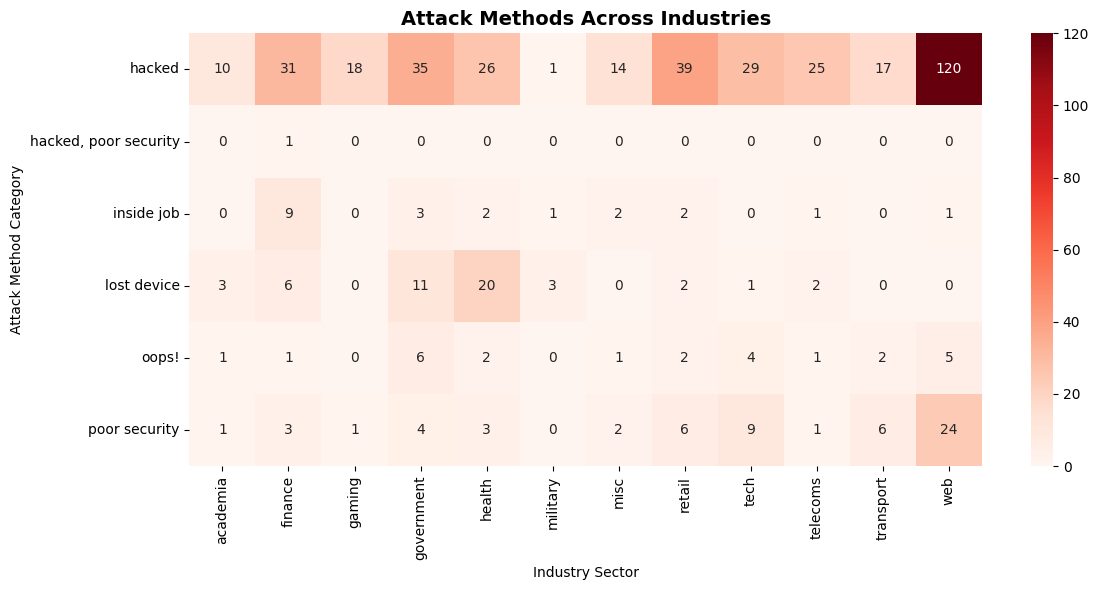

In [23]:
heatmap_data = pd.crosstab(
    df['method'],
    df['sector']
)

fig, ax = plt.subplots(figsize=(12,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='d',
    cmap='Reds',
    ax=ax
)

ax.set_title(
    'Attack Methods Across Industries',
    fontsize=14,
    fontweight='bold'
)

ax.set_xlabel('Industry Sector')
ax.set_ylabel('Attack Method Category')

fig.tight_layout()

# fig.savefig(
#     'heatmap.png',
#     dpi=300,
#     bbox_inches='tight'
# )

plt.show()

### Findings

- Hacking is the dominant attack method across nearly all industries.
- Web, government, and retail sectors experience the highest frequency of breach incidents.
- Lost devices and poor security practices contribute to breaches but occur less frequently than hacking.

## Visualization 2: Records Exposed by Industry

### Business Question

Which industries account for the largest volume of exposed records?

In [29]:
industry_records = (
    df.groupby('sector')['records lost']
      .sum()
      .reset_index()
)

fig = px.treemap(
    industry_records,
    path=['sector'],
    values='records lost',
    title='Industry Share of Exposed Records'
)

fig.update_layout(
    title_x=0.5
)

# fig.write_image(
#     'treemap.png',
#     scale=2
# )

fig.show()

### Findings

- Web organizations account for the largest volume of exposed records.
- Government and telecommunications sectors also contribute significantly to total exposure.
- A relatively small number of industries account for most compromised records.

## Visualization 3: Global Data Breach Impact Over Time

### Business Question

How has the scale of major data breaches changed over time?

In [25]:
fig = px.scatter(
    df,
    x='year',
    y='records lost',
    size='records lost',
    color='sector',
    hover_name='organisation',
    title='Global Data Breach Impact Over Time',
    height=600
)

fig.update_layout(
    title_x=0.5,
    xaxis_title='Year of Breach',
    yaxis_title='Records Exposed (Count)'
)

fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)

# fig.write_image(
#     'bubble_chart.png',
#     scale=2
# )

fig.show()

### Findings

- The scale of major breaches has increased substantially over time.
- Several billion-record incidents occurred after 2018.
- Recent breaches demonstrate that cybersecurity risks continue to grow despite increased security awareness.

## Visualization 4: Top 10 Largest Data Breaches

### Business Question

Which organizations experienced the largest data breaches in history?

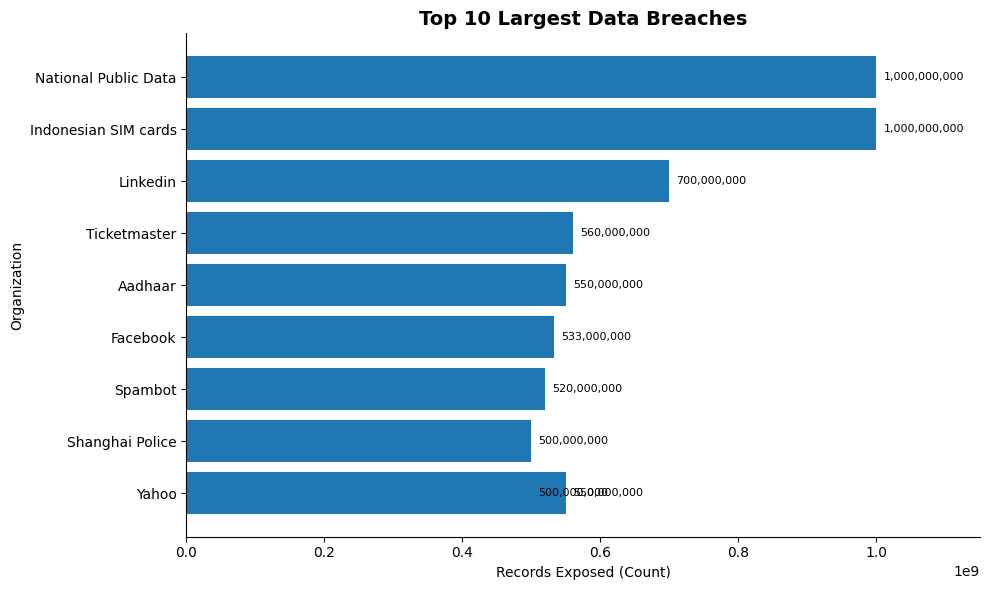

In [26]:
top_breaches = (
    df[['organisation', 'records lost']]
      .sort_values(
          by='records lost',
          ascending=False
      )
      .head(10)
)

fig, ax = plt.subplots(figsize=(10,6))

bars = ax.barh(
    top_breaches['organisation'][::-1],
    top_breaches['records lost'][::-1]
)

ax.set_title(
    'Top 10 Largest Data Breaches',
    fontsize=14,
    fontweight='bold'
)

ax.set_xlabel('Records Exposed (Count)')
ax.set_ylabel('Organization')

ax.set_xlim(
    0,
    top_breaches['records lost'].max() * 1.15
)

for bar in bars:

    width = bar.get_width()

    ax.text(
        width + (top_breaches['records lost'].max()*0.01),
        bar.get_y() + bar.get_height()/2,
        f'{width:,.0f}',
        va='center',
        fontsize=8
    )

ax.grid(False)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.tight_layout()

plt.show()

### Findings

- Several breaches exposed hundreds of millions of records.
- Government and web organizations account for many of the largest incidents.
- A small number of breaches contribute disproportionately to total records exposed.

## Visualization 5: Industry Risk Ranking

### Business Question

Which industries present the highest overall cybersecurity risk?

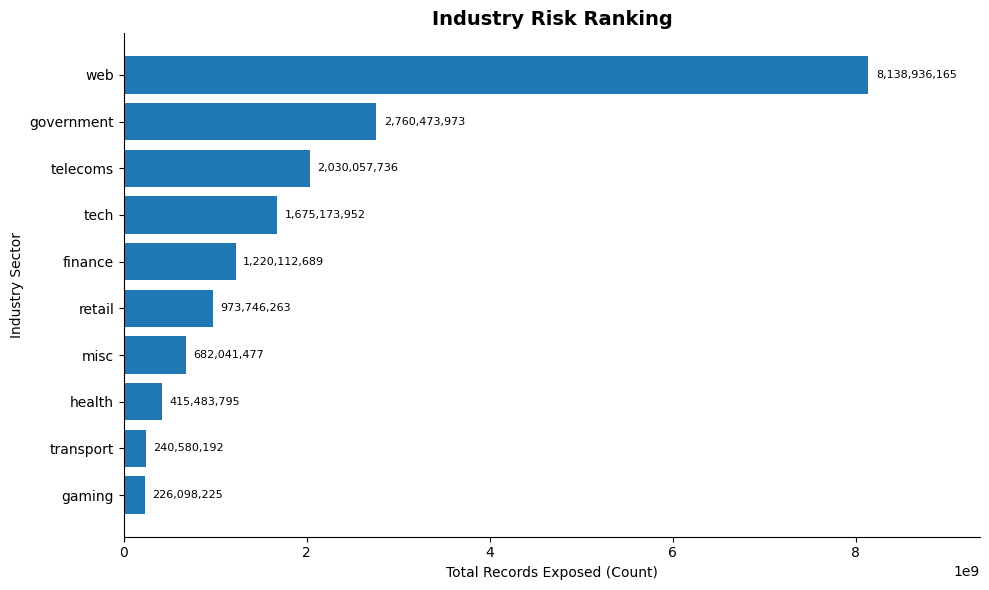

In [27]:
sector_risk = (
    df.groupby('sector')
      .agg(
          total_records_lost=('records lost','sum')
      )
      .sort_values(
          by='total_records_lost',
          ascending=False
      )
      .head(10)
)

fig, ax = plt.subplots(figsize=(10,6))

bars = ax.barh(
    sector_risk.index[::-1],
    sector_risk['total_records_lost'][::-1]
)

ax.set_title(
    'Industry Risk Ranking',
    fontsize=14,
    fontweight='bold'
)

ax.set_xlabel('Total Records Exposed (Count)')
ax.set_ylabel('Industry Sector')

ax.set_xlim(
    0,
    sector_risk['total_records_lost'].max()*1.15
)

for bar in bars:

    width = bar.get_width()

    ax.text(
        width + (sector_risk['total_records_lost'].max()*0.01),
        bar.get_y() + bar.get_height()/2,
        f'{width:,.0f}',
        va='center',
        fontsize=8
    )

ax.grid(False)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.tight_layout()

plt.show()

### Findings

- Web-based organizations account for the largest cumulative exposure.
- Government and telecommunications sectors also experience significant breach impact.
- Industry risk is concentrated among data-intensive sectors.

## Executive Summary

Key observations from the analysis include:

1. Hacking remains the most common attack method across industries.
2. Web, government, and telecommunications sectors account for the largest number of exposed records.
3. Data breaches have increased in severity over time, with several incidents exposing hundreds of millions or billions of records.
4. A relatively small number of organizations and industries contribute disproportionately to global data exposure.
5. The findings highlight the importance of cybersecurity controls, data protection practices, and continuous risk management.

## Conclusion

This analysis examined historical data breaches to understand industry risk, attack methods, and breach impact.

The results show that hacking remains the dominant threat vector, while web and government sectors experience the largest exposure. Breach sizes have increased substantially over time, highlighting the growing importance of cybersecurity investments and data protection strategies.